## Data analysis- score distribution

In [1]:

import yaml

from final_exp_data_converter import convert_multiple_experiments
from main import SURVEY_VERSION, RAW_DATA, PROCESSED_XLSX_DATA, OLD_XLSX_DATA, MERGED_XLSX_DATA, DISTANCE_MATRIX, GROUP_SPACE_DATA, SUBJECT_WEIGHTS_DATA, INDIVIDUAL_GROUND_TRUTH, PLOTS_FOLDER, FA_FOLDER, LOPO_FOLDER, L2PO_FOLDER, STIMULI_NAMES, PARTICIPANTS_TO_EXCLUDE, TRANSFORMATIONS

with open('repo.yml', 'r') as file:
        repository_data = yaml.safe_load(file)

survey_version: str = repository_data[SURVEY_VERSION]
raw_data_paths: list[str] = repository_data[RAW_DATA]
processed_xlsx_data_path: str = repository_data[PROCESSED_XLSX_DATA]
old_xlsx_data_paths: list[str] = repository_data[OLD_XLSX_DATA]
merged_xlsx_data_path: str = repository_data[MERGED_XLSX_DATA]
distance_matrix_path: str = repository_data[DISTANCE_MATRIX]
group_space_data_path: str = repository_data[GROUP_SPACE_DATA]
subject_weights_data_path: str = repository_data[SUBJECT_WEIGHTS_DATA]
individual_ground_truth_path: str = repository_data[INDIVIDUAL_GROUND_TRUTH]
plots_folder_path: str = repository_data[PLOTS_FOLDER]
fa_folder_path: str = repository_data[FA_FOLDER]
lopo_folder_path: str = repository_data[LOPO_FOLDER]
l2po_folder_path: str = repository_data[L2PO_FOLDER]
stimuli_names: list[str] = repository_data[STIMULI_NAMES]
participants_to_exclude: list[str] = repository_data[PARTICIPANTS_TO_EXCLUDE]
transformations: dict[str, bool] = repository_data[TRANSFORMATIONS]

correct_participants= ['GFGzP', 'KWgkc', 'EXAMPLE', 'tMGNS', 'urJvc', 'yb3T2', '4FoNM', '5KB3V', 'CoQmx',
 'Cr1sTi', 'F5tXL', 'F8mDn', 'LR96S', 'PPjCX', 'VckNZ', 'hMHEK1', 'wohkw', '6GSd4',
 '8vDRG', 'Fjil72', 'Fyt7d', 'G4Egk', 'Gftw5', 'KoG5ii', 'M4t7k', 'O1pGR',
 'XhsN0o', 'kH4Dd', 'GHft8', 'WYuvqk', 'XPI3pA', 'h2yD5h', '7yqP3', 'G5XzoP',
 'NMy2s', 'Xd3foP9', 'gf5X', 'A5feTy', 'CVgs2', 'Dwf5T', 'ERqc8', 'G4dLl', 'Gr33d',
 'Hx7dO', 'Kgh4P3', 'SI3pa2', 'V9D5x', 'sop2d', '6k6gw', 'D7GcxxFf3', 'FWvvb87',
 'FcXX1', 'K34LOp', 'KLO33', 'Lso2g', 'Ou4tR', 'P67Dftt', 'SxRtt99', 'V11GHjjk',
 'VBr4ssd', 'XCv32m', 'XfdEE1', 'rt8Ye0r']

if survey_version in ['version_1', 'version_5', 'version_final']:
    emotions_to_use = ['Amused*', 'Angry*', 'Anxious*', 'Bored*', 'Calm*', 'Content*', 'Excited*', 'Fearful*',
                        'Happy*', 'Negative*', 'Positive*', 'Sad*']

    positive_emotions = ['Happy*', 'Positive*']
    negative_emotions = ['Angry*', 'Fearful*', 'Negative*', 'Sad*', 'Anxious*']

else:
    emotions_to_use = ['Amused*', 'Angry*', 'Bored*', 'Calm*', 'Content*', 'Disgust*', 'Excited*', 'Fearful*',
                        'Happy*', 'Negative*', 'Positive*', 'Sad*']

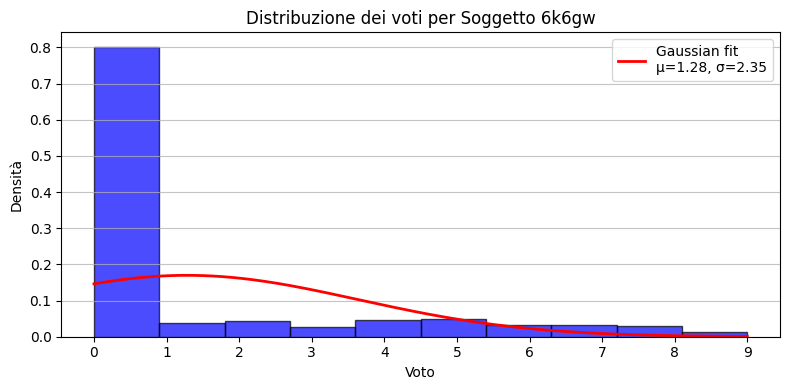

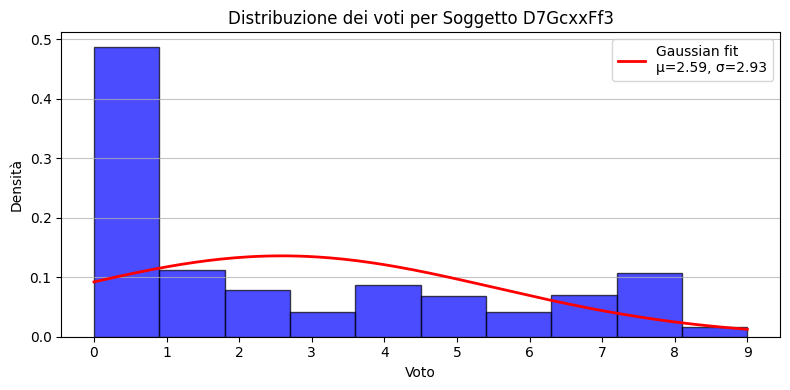

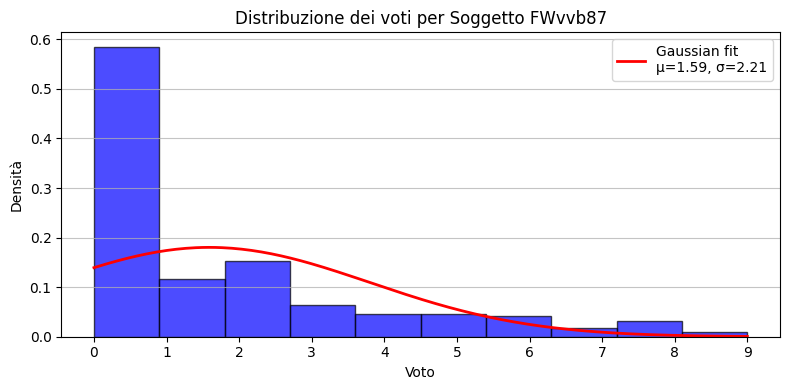

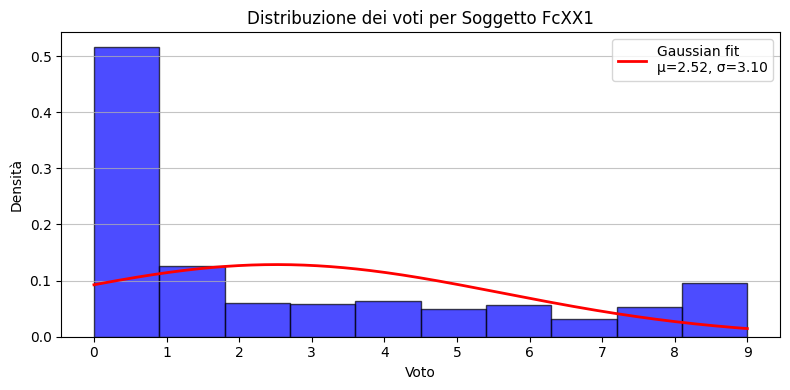

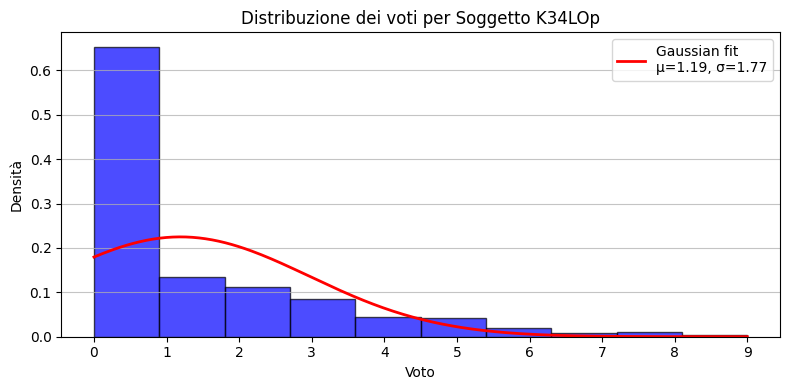

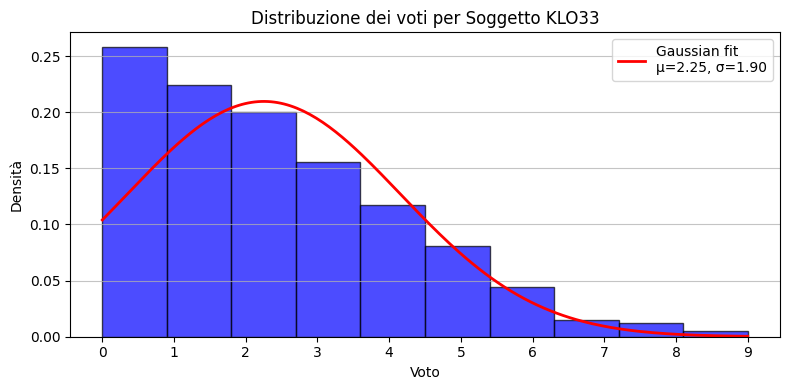

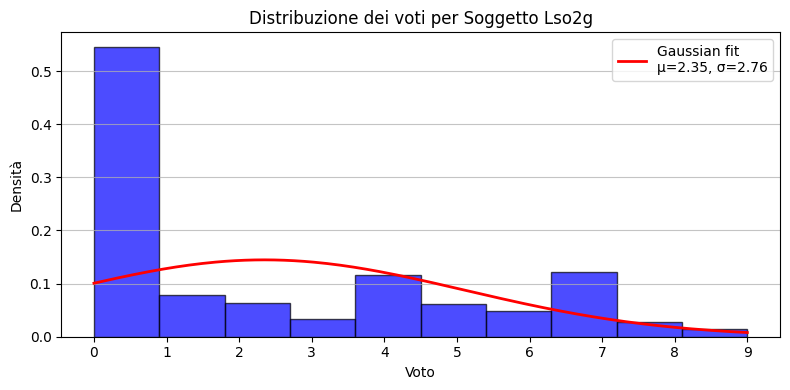

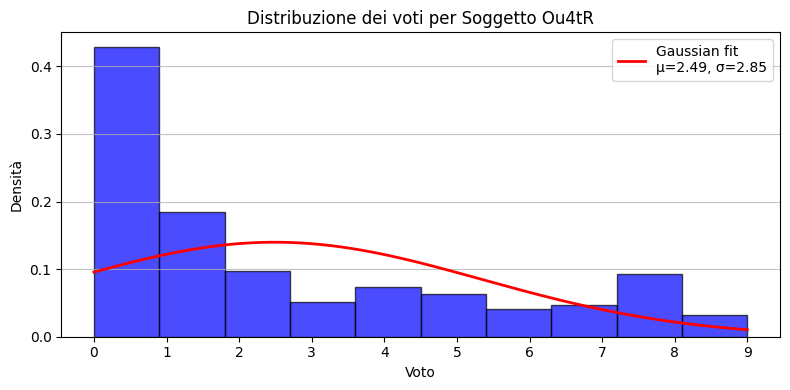

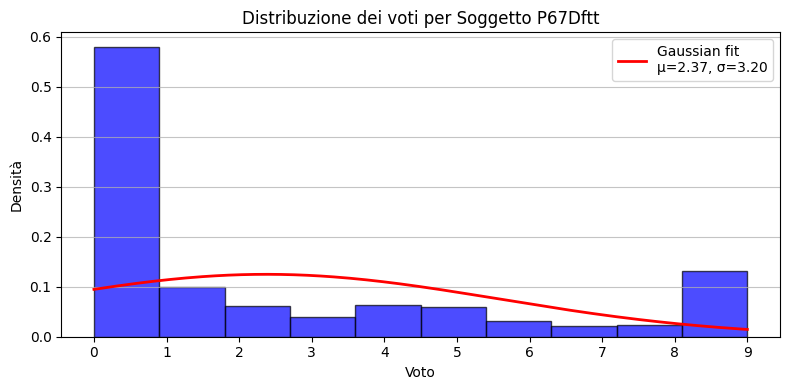

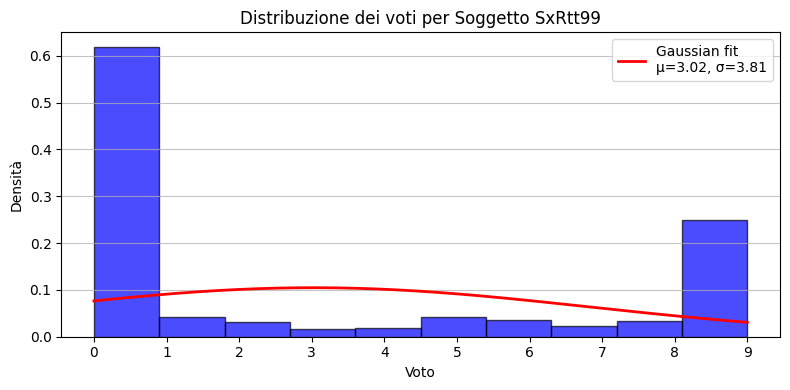

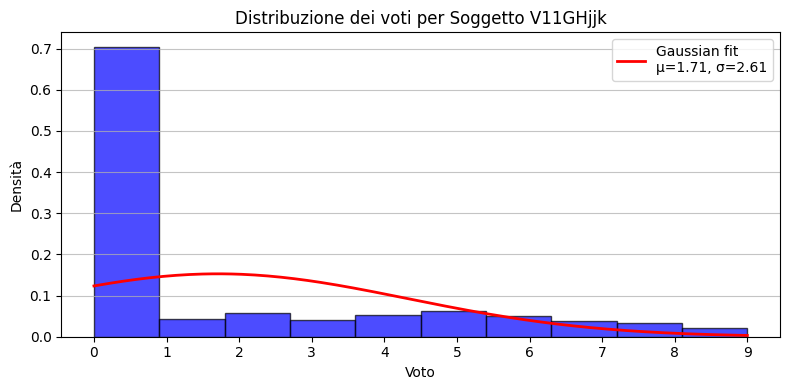

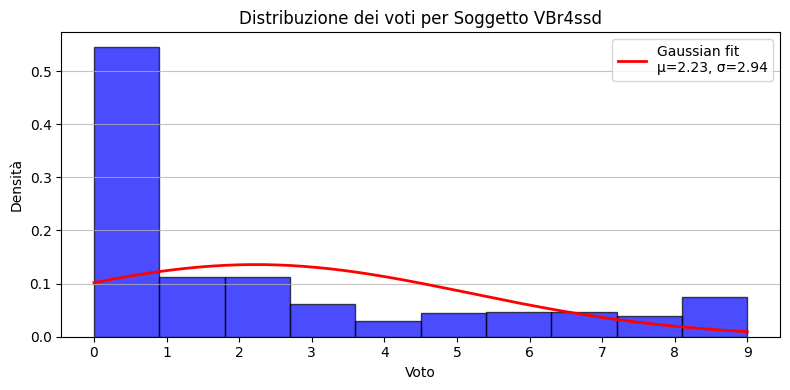

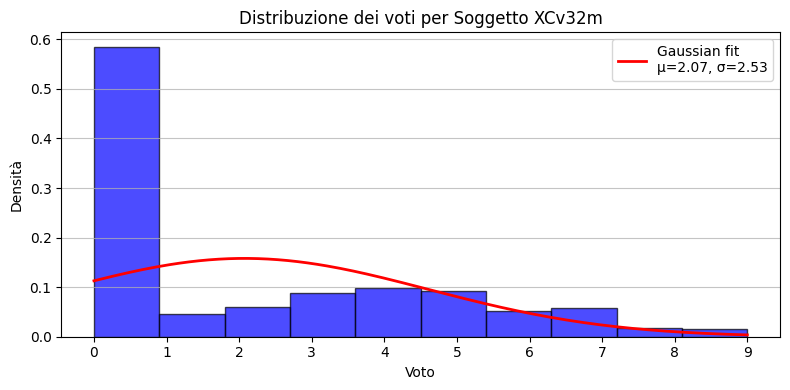

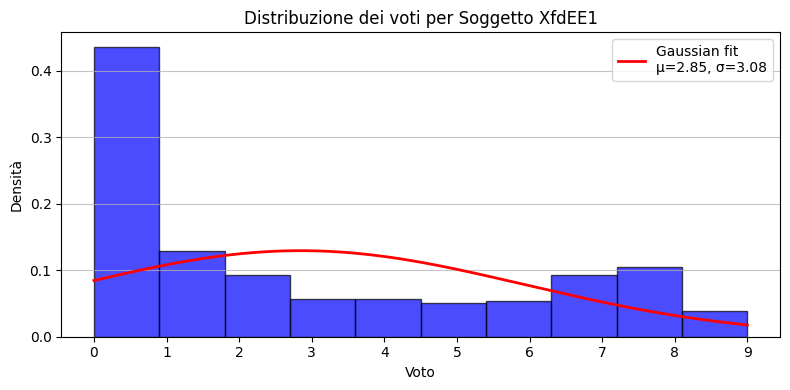

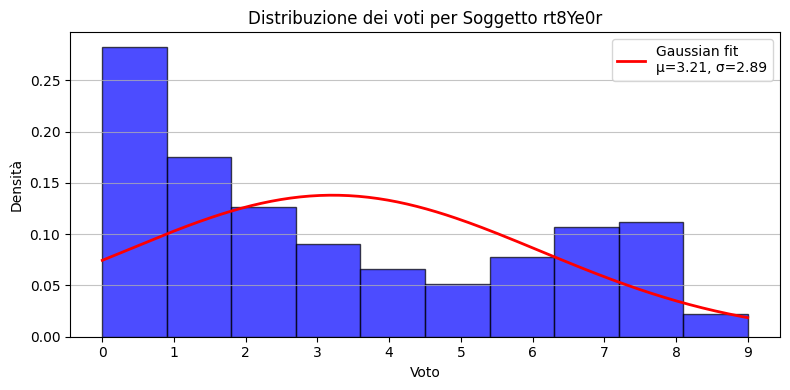

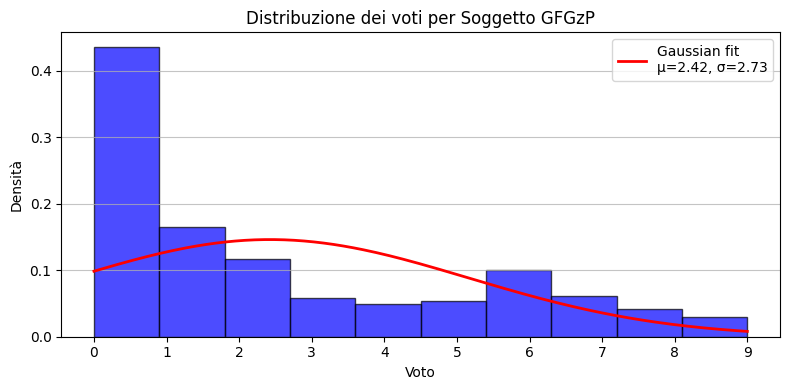

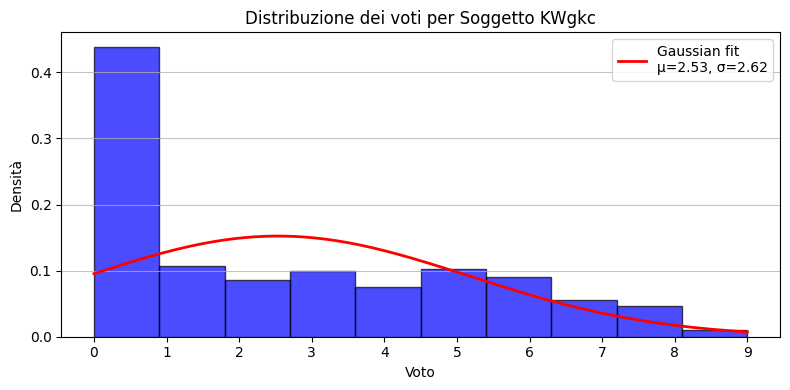

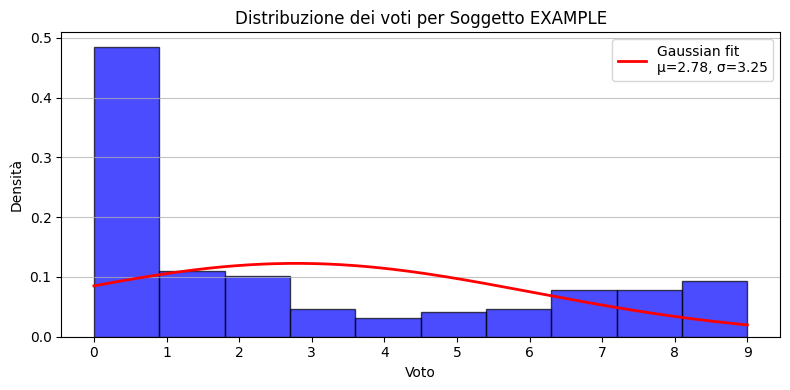

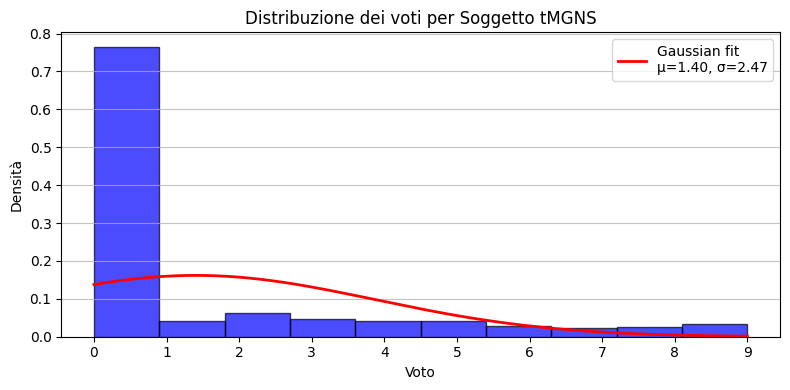

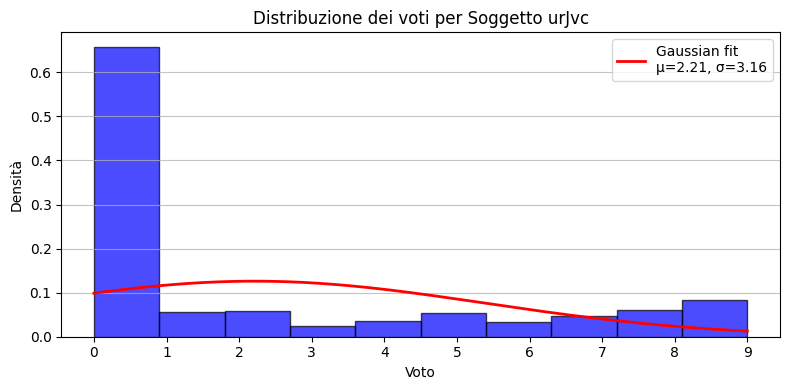

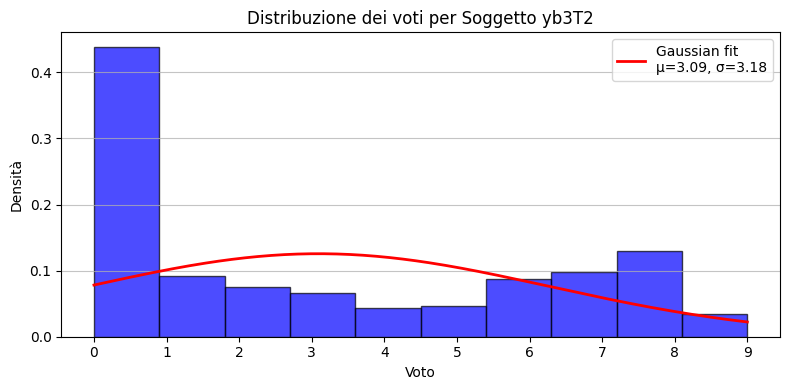

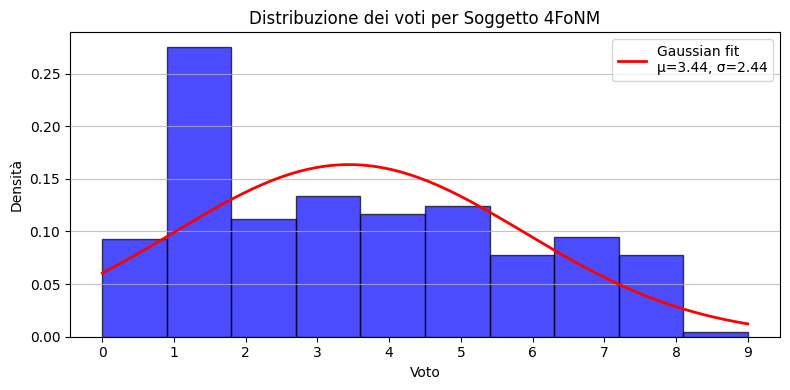

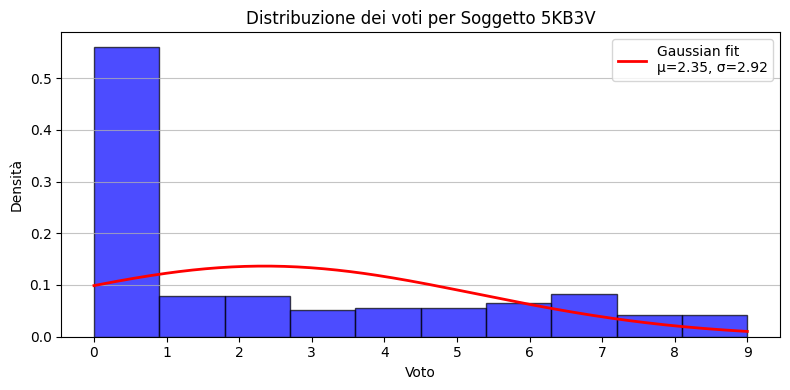

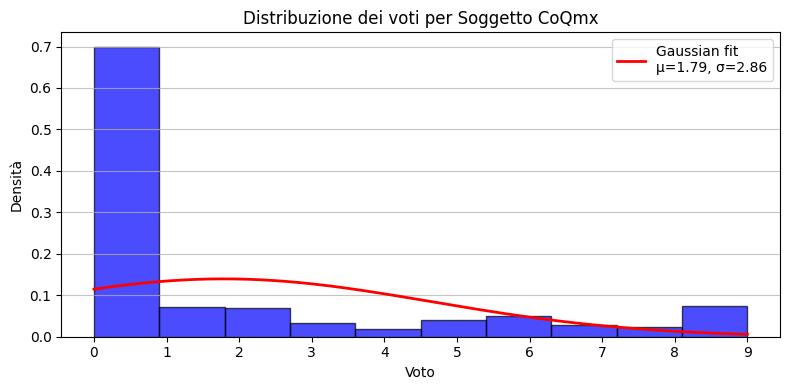

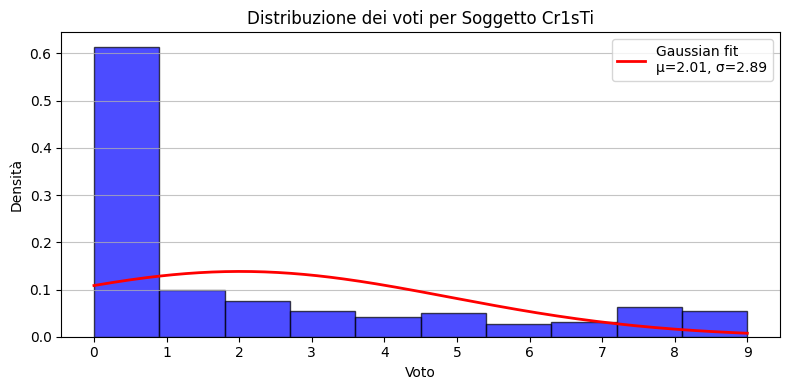

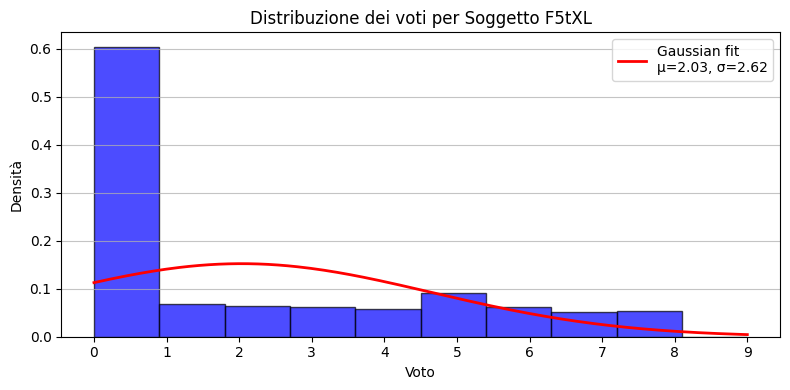

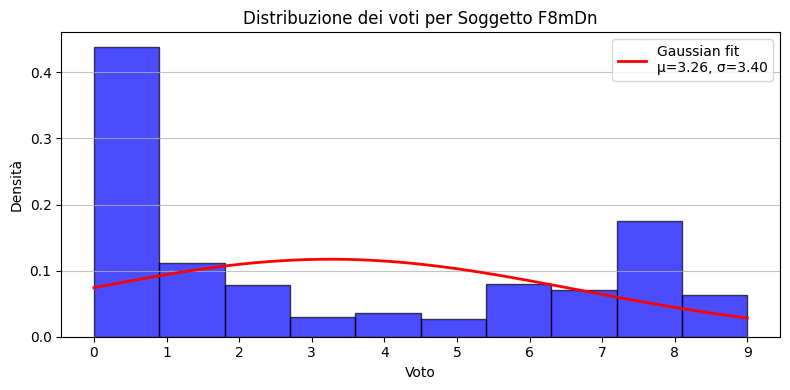

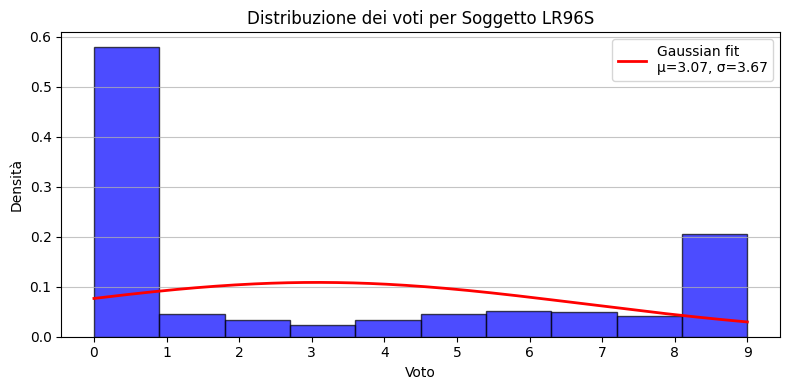

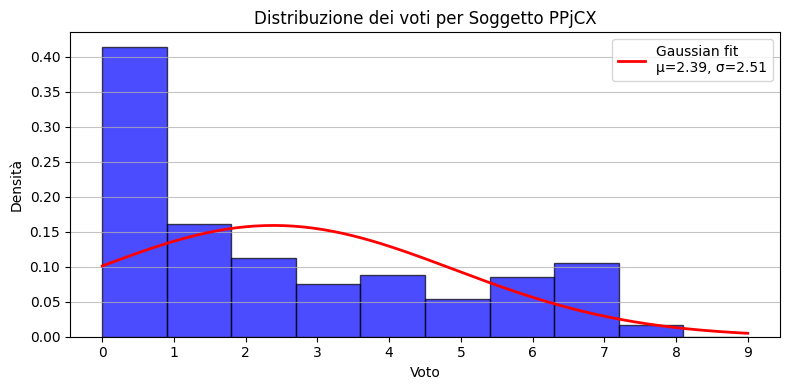

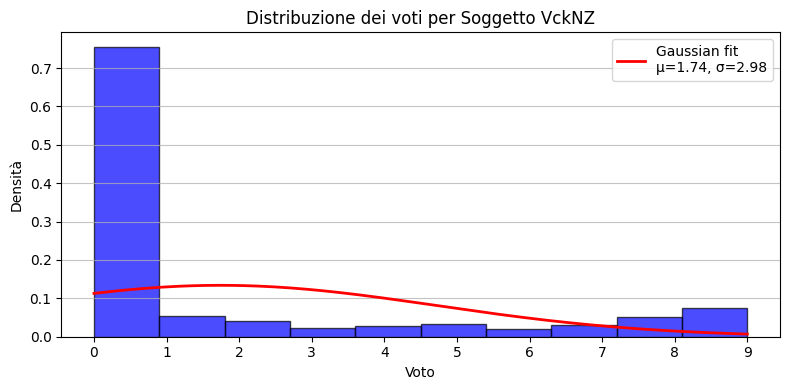

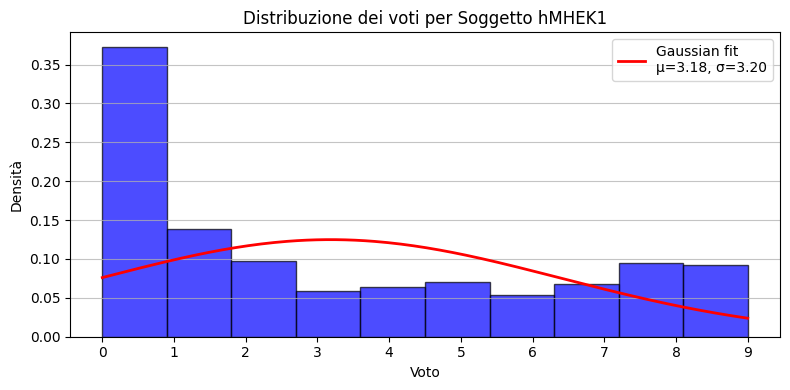

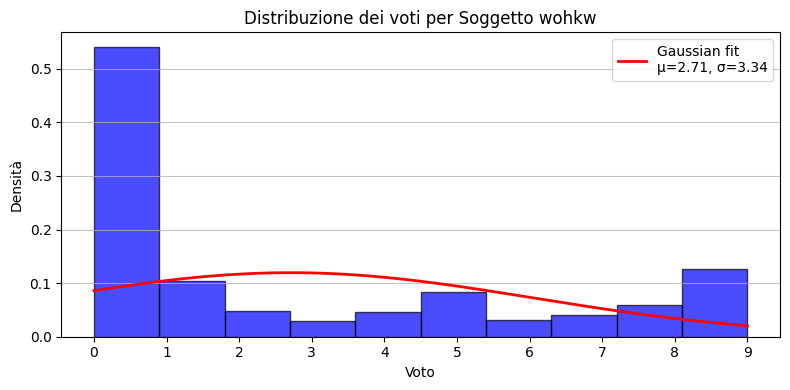

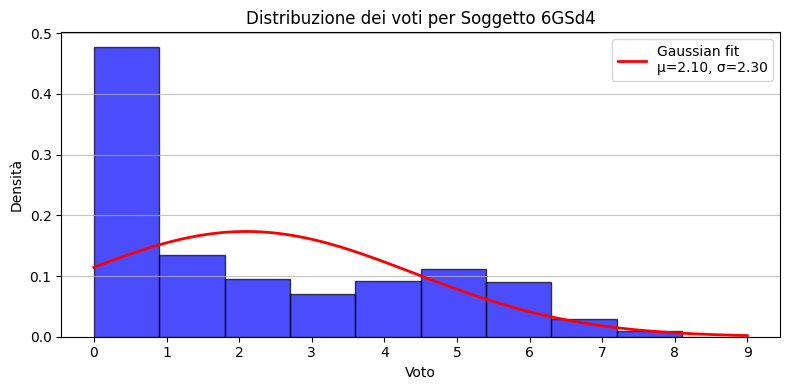

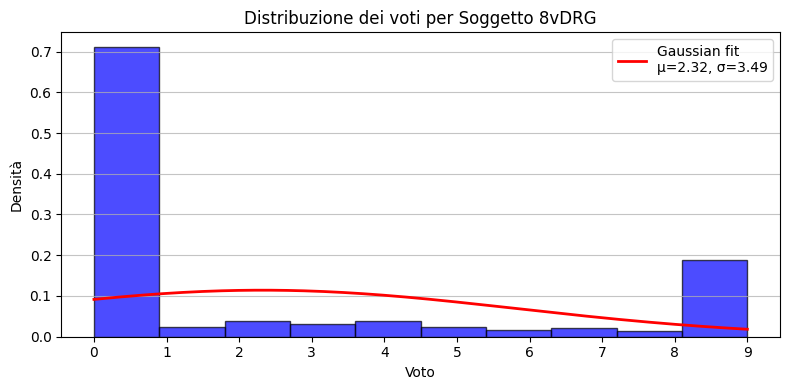

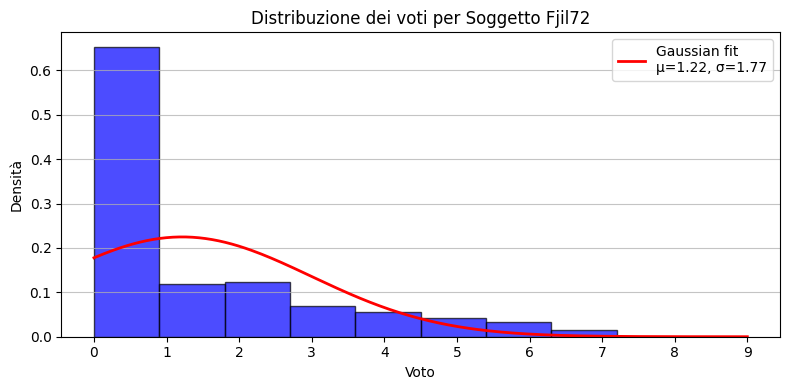

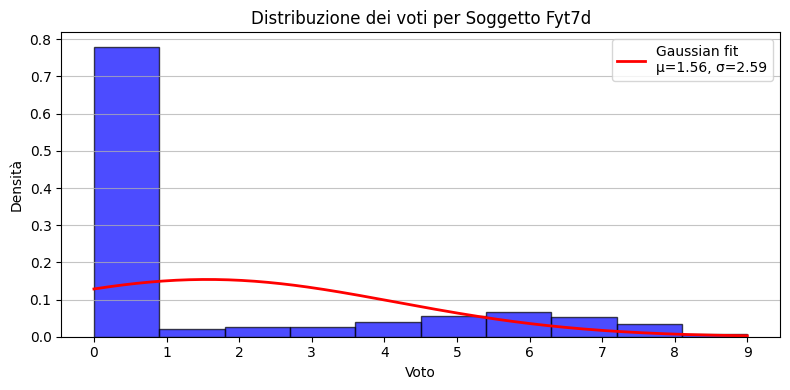

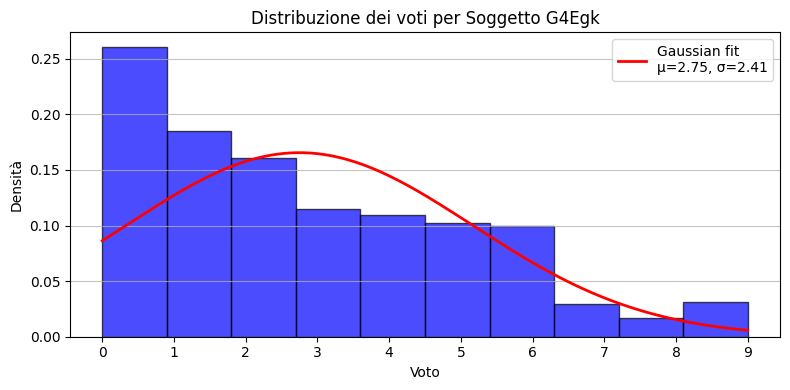

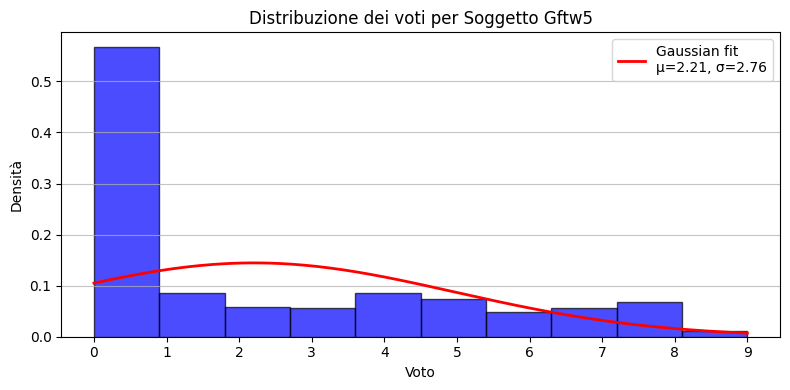

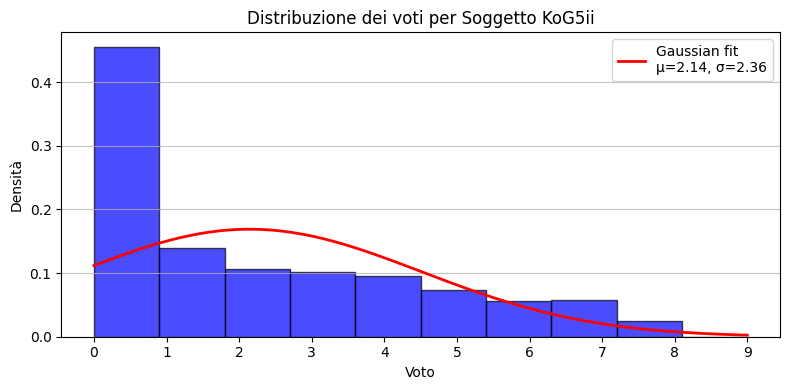

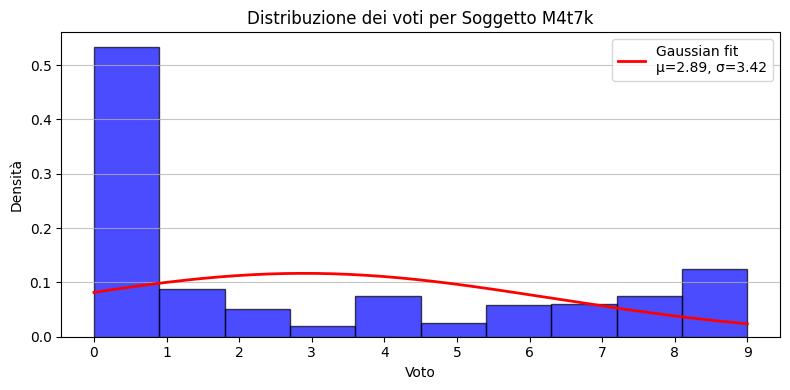

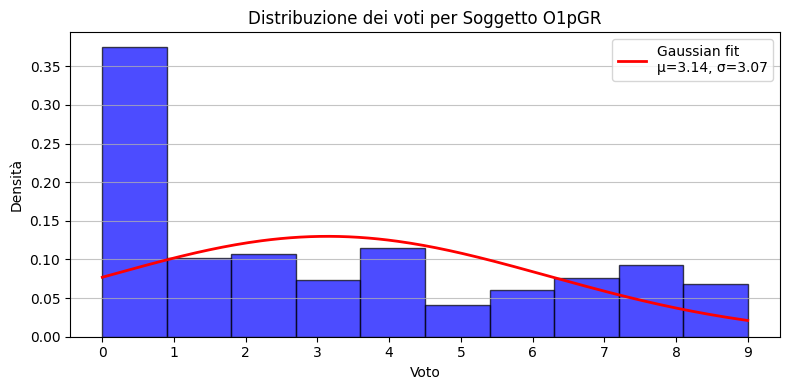

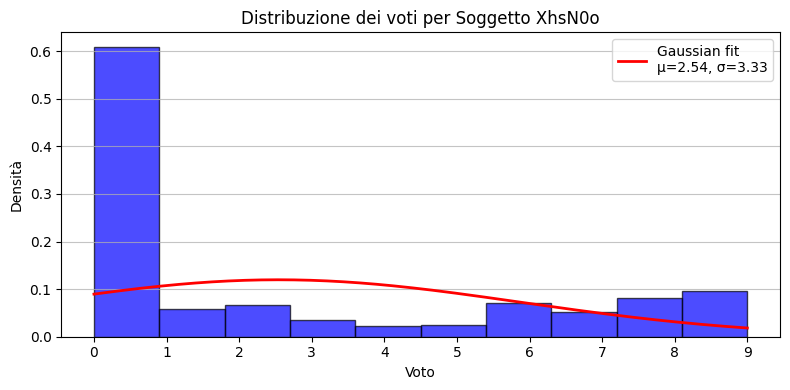

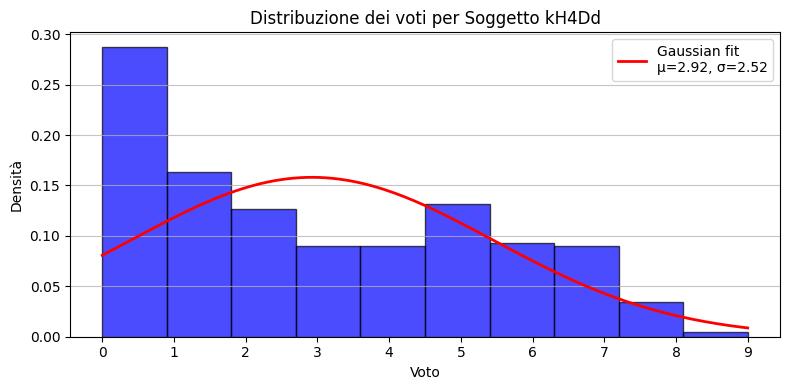

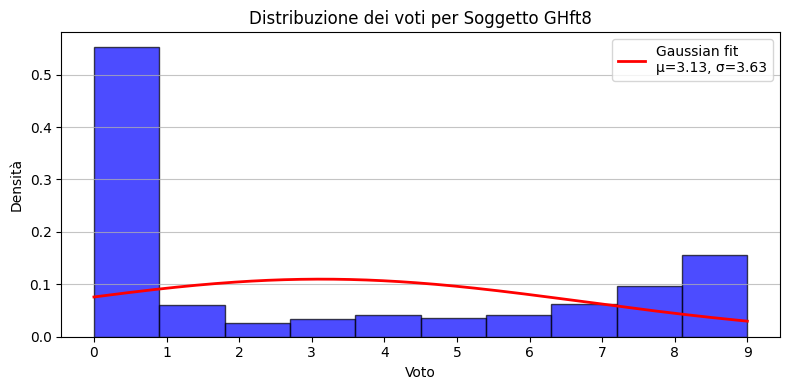

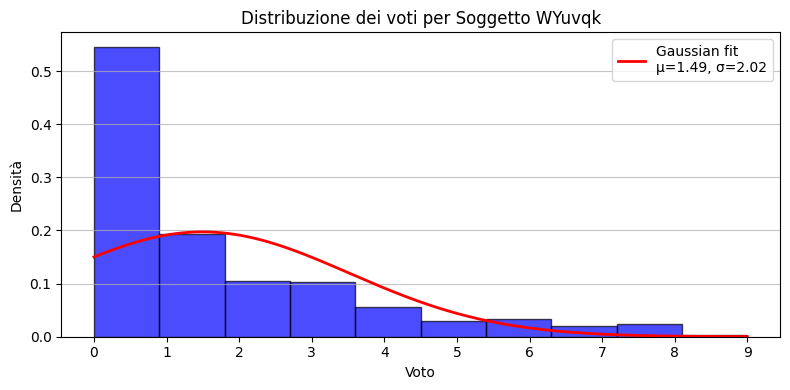

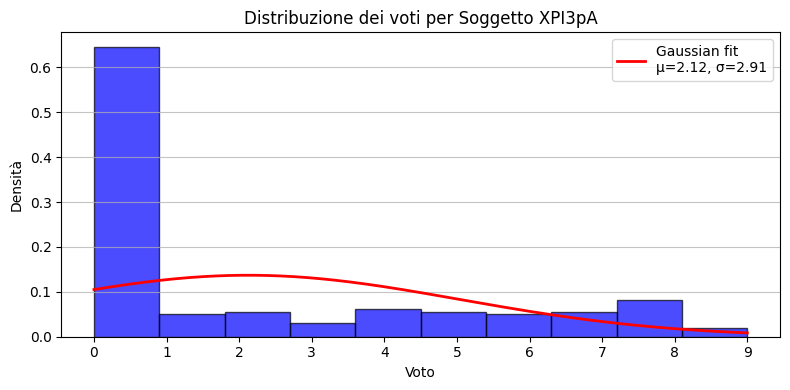

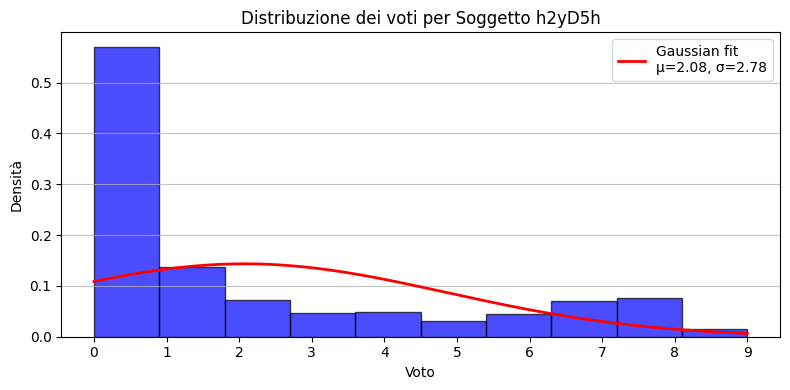

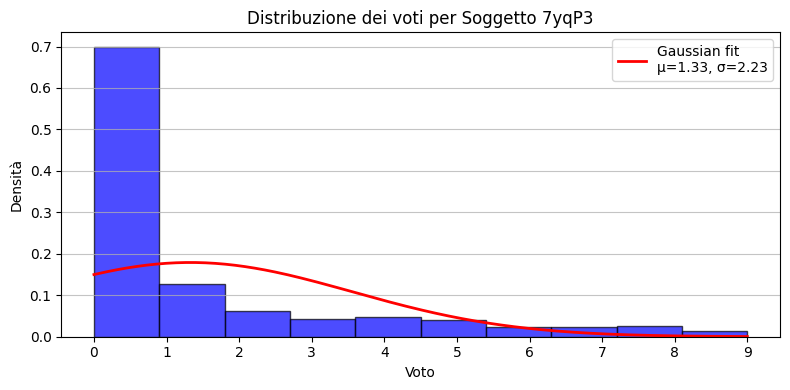

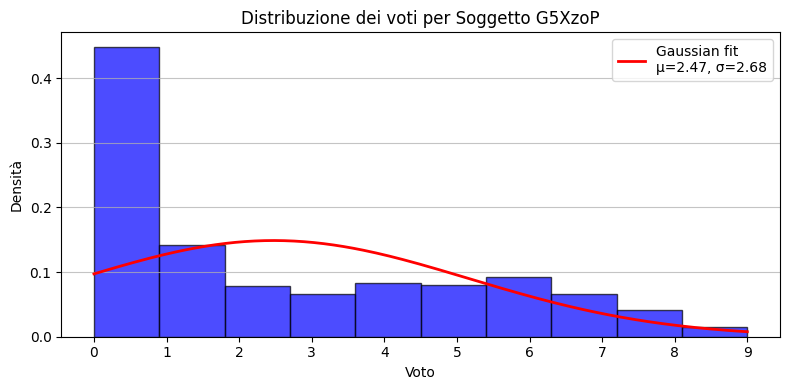

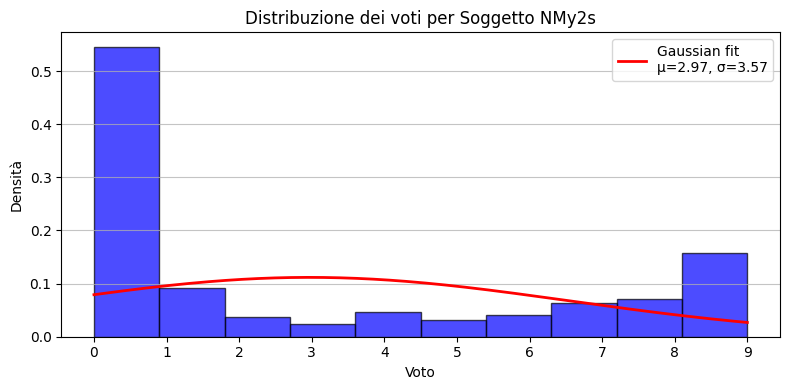

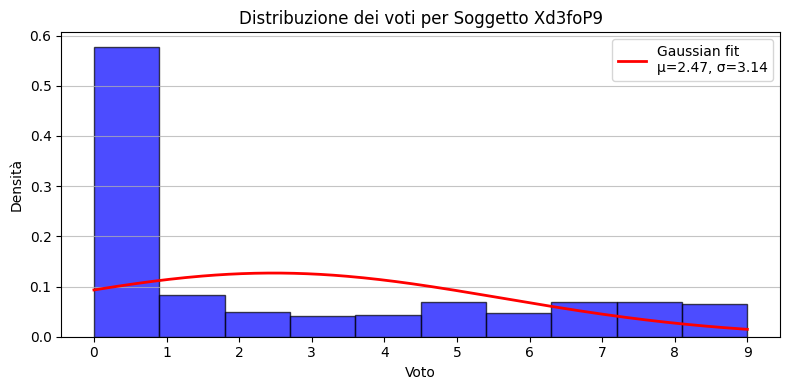

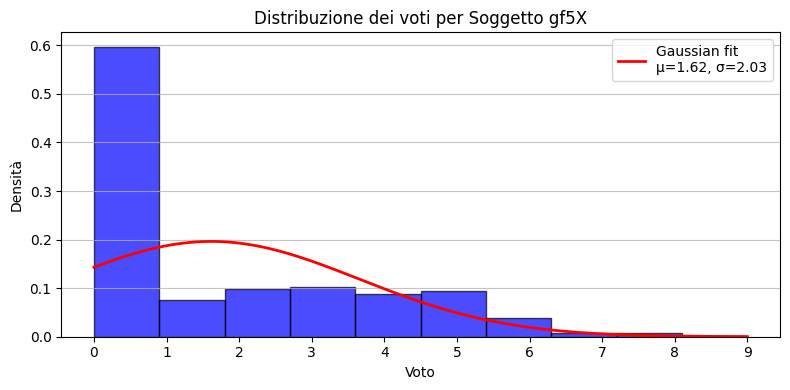

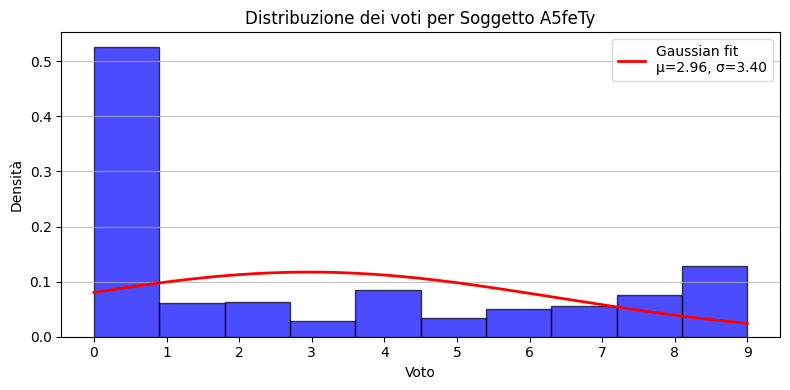

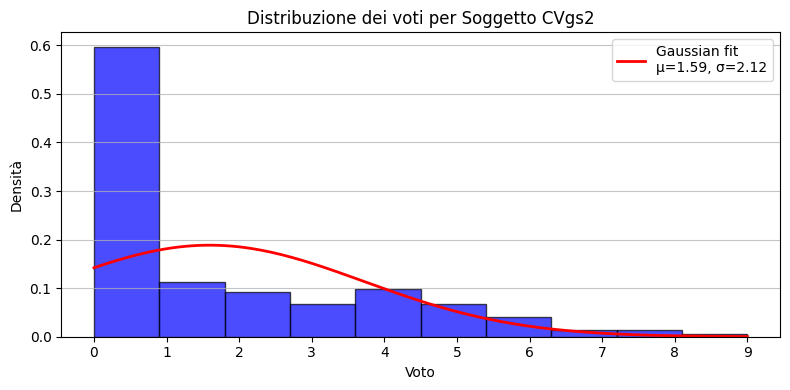

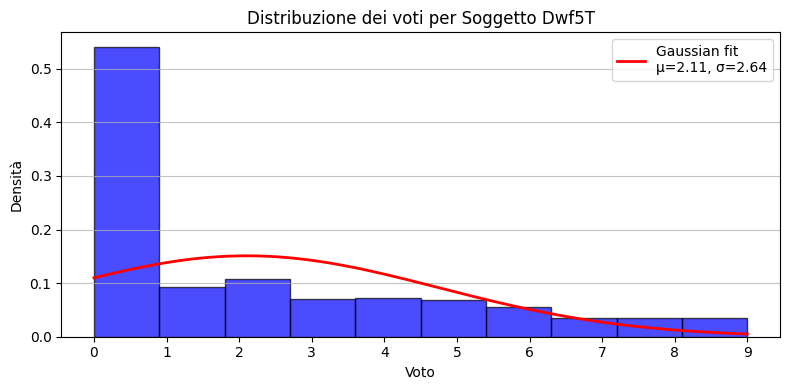

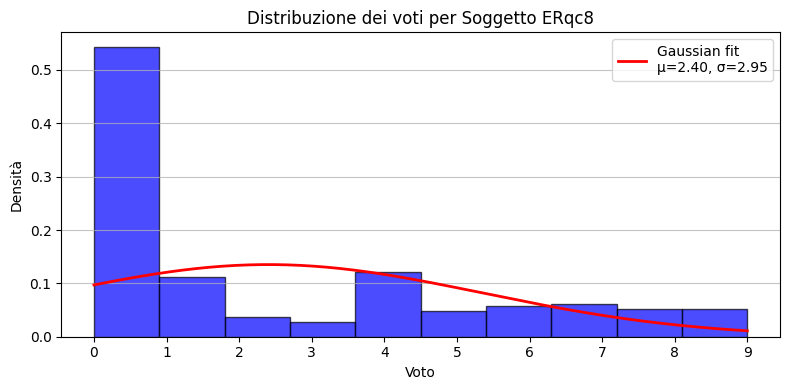

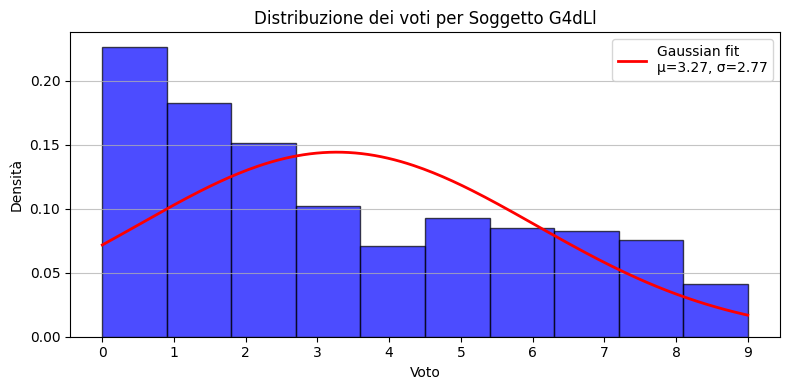

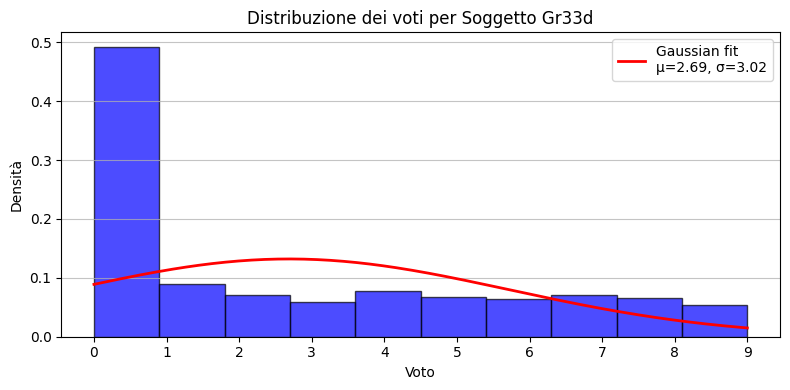

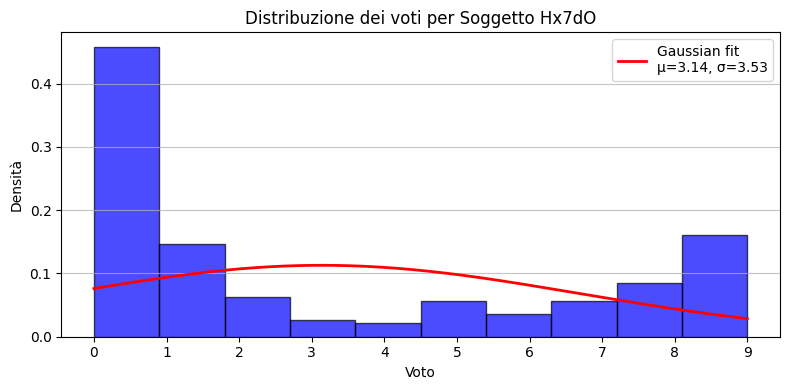

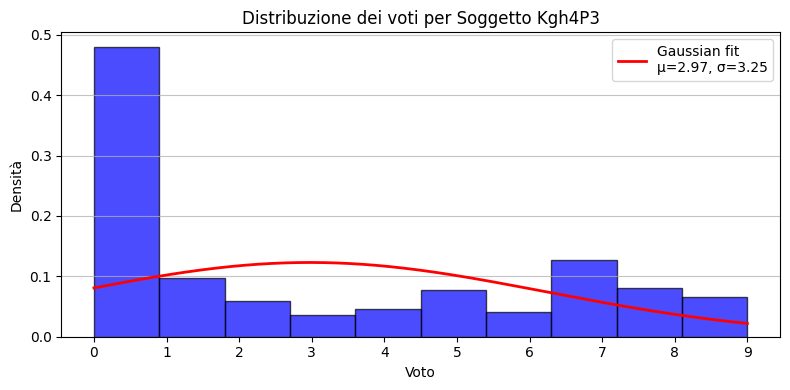

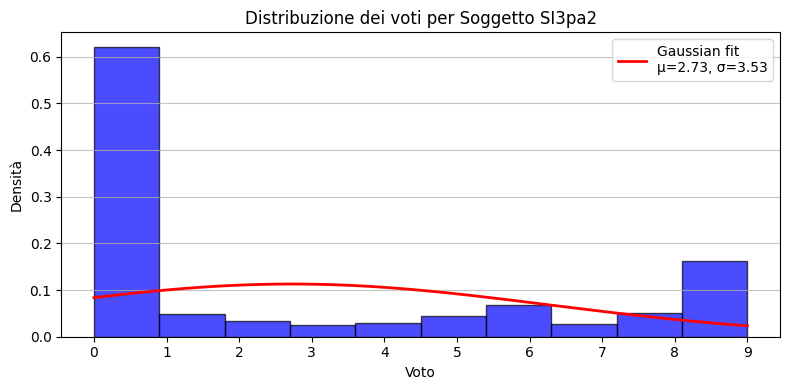

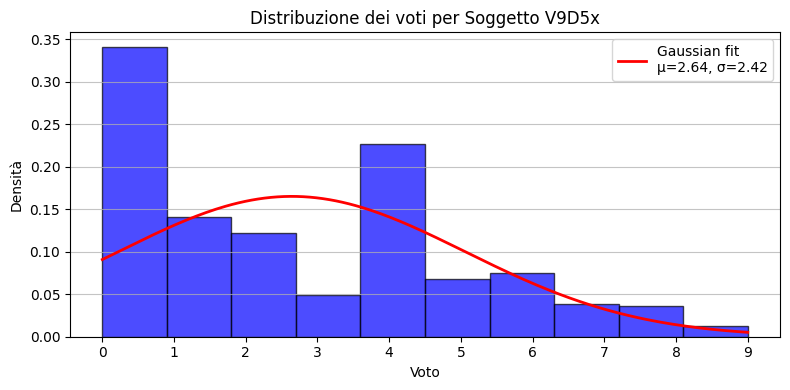

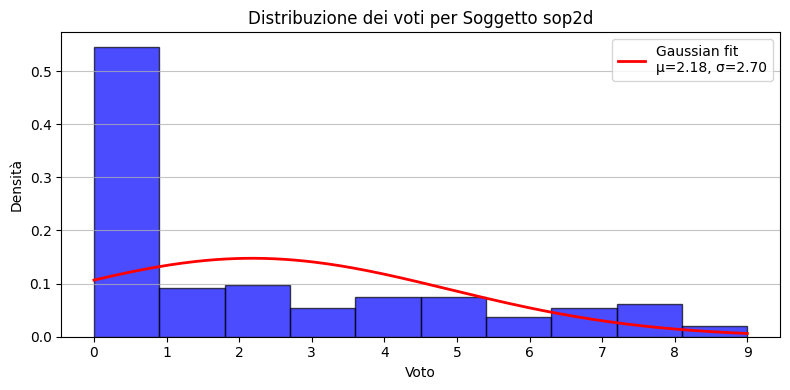

In [4]:
path = 'preprocessed_data_standard_normalization.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Carica i dati
data = pd.read_csv(path)

# Assicurati che emotions_to_use sia una lista di colonne esistente
# es. emotions_to_use = ['Happy_normalized', 'Sad_normalized', ...]
# Se l'hai definita altrove nel notebook, rimuovi la linea seguente
# emotions_to_use = [...]

# Seleziona solo le colonne interessate
data = data[['Participant'] + emotions_to_use]

for participant in data['Participant'].unique():
    # tutte le righe del partecipante e solo le colonne emozioni
    emotion_df = data.loc[data['Participant'] == participant, emotions_to_use]
    # appiattisci in un vettore 1D di valori numerici
    values = emotion_df.to_numpy().ravel()
    # rimuovi eventuali NaN
    values = values[~np.isnan(values)]

    if values.size == 0:
        print(f"{participant}: nessun valore disponibile")
        continue

    mu = values.mean()
    sigma = values.std(ddof=0)

    plt.figure(figsize=(8, 4))
    # usa density=True se vuoi confrontare la pdf (y in densità)
    counts, bins, patches = plt.hist(values, bins=10, range=(0, 9), alpha=0.7,
                                    color='blue', edgecolor='black', density=True)

    x = np.linspace(0, 9, 200)
    if sigma > 0:
        pdf = norm.pdf(x, mu, sigma)
        plt.plot(x, pdf, 'r-', linewidth=2, label=f'Gaussian fit\nμ={mu:.2f}, σ={sigma:.2f}')
    else:
        plt.axvline(mu, color='r', linestyle='--', label=f'Constant value μ={mu:.2f}')

    plt.title(f'Distribuzione dei voti per Soggetto {participant}')
    plt.xlabel('Voto')
    plt.ylabel('Densità')
    plt.xticks(range(0, 10))
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    # Assicurati che la cartella esista prima di salvare
    import os
    out_dir = 'img/participant_analysis'
    os.makedirs(out_dir, exist_ok=True)
    # Salva la figura prima di show() per evitare backend che la svuotano
    plt.savefig(os.path.join(out_dir, f'{participant}_histogram.png'), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

## Samples

*Outliers:*
<img src='img/participant_analysis/LR96S_histogram.png'>
<img src='img/participant_analysis/SxRtt99_histogram.png'>


*best reconstructed*
<img src='img/participant_analysis/V9D5x_histogram.png'>